##1.Standardization

```
Primary Goal:
  Re-center data distributions and scale by variance.

Range:
  Unbounded (though most values fall between -3 and +3)
```
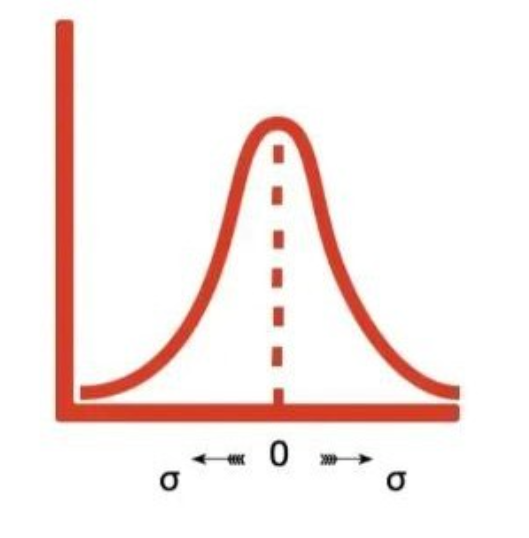


In [1]:
from sklearn.preprocessing import StandardScaler

In [7]:
data = [[0, 0],
        [0, 0],
        [1, 1],
        [1, 1]]

scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
newdata = scaler.fit_transform(data)
print(newdata)

[[-1. -1.]
 [-1. -1.]
 [ 1.  1.]
 [ 1.  1.]]


In [5]:
data = [[-1, 2],
        [-0.5, 6],
        [0, 10],
        [1, 18]]

scaller = StandardScaler()
newdata = scaller.fit_transform(data)
print(newdata)

[[-1.18321596 -1.18321596]
 [-0.50709255 -0.50709255]
 [ 0.16903085  0.16903085]
 [ 1.52127766  1.52127766]]


##2.MinMaxScaler (Normalization)

```
Primary Goal:
  Constrain data into a strict numerical range.

Range:
   or [-1, +1] or [0 , +1]
```
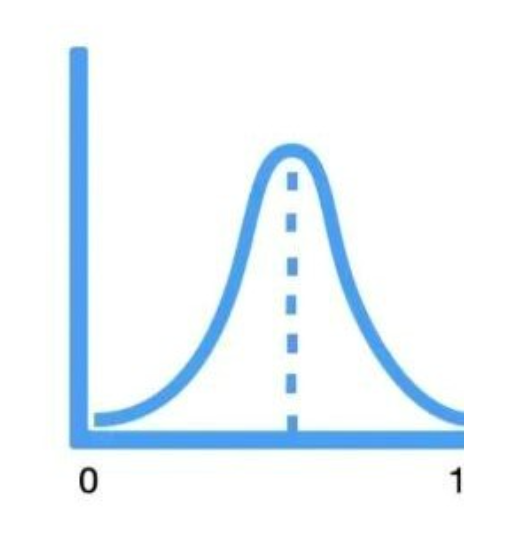

In [16]:
from sklearn.preprocessing import MinMaxScaler

data = [[-1, 2],
        [-0.5, 6],
        [0, 10],
        [1, 18]]

scaler = MinMaxScaler(copy=True, feature_range=(0,1))
newdata = scaler.fit_transform(data)

print(scaler.data_max_, "\n")
print(scaler.data_min_, "\n")

print(newdata)


[ 1. 18.] 

[-1.  2.] 

[[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [1.   1.  ]]


##3.Normalizer
```
Primary Goal:
  Move row by row

Methods:
  l1:
    sum the values, and
    divide each value by the total

  l2:
    Divide each value in the
    row by the (square root
    of the sum of the
    squares of all the values)

  max:
    Divide each value in the
    row by the (max value in this row)
```

In [19]:
from sklearn.preprocessing import Normalizer

data = [[-1, 2],
        [-0.5, 6],
        [0, 10],
        [1, 18]]

scaler = Normalizer(copy=True, norm='l1')
newdata = scaler.fit_transform(data)
print(newdata, "\n")

scaler = Normalizer(copy=True, norm='l2')
newdata = scaler.fit_transform(data)
print(newdata, "\n")

scaler = Normalizer(copy=True, norm='max')
newdata = scaler.fit_transform(data)
print(newdata, "\n")

[[-0.33333333  0.66666667]
 [-0.07692308  0.92307692]
 [ 0.          1.        ]
 [ 0.05263158  0.94736842]] 

[[-0.4472136   0.89442719]
 [-0.08304548  0.99654576]
 [ 0.          1.        ]
 [ 0.05547002  0.99846035]] 

[[-0.5         1.        ]
 [-0.08333333  1.        ]
 [ 0.          1.        ]
 [ 0.05555556  1.        ]] 



##4.MaxAbsScaler
```
  It is exactly the same as
  the Nomralizer, but it
  moves column by column in
  the same third method only
  "max"
```

In [21]:
from sklearn.preprocessing import MaxAbsScaler

data = [[-1, 2],
        [-0.5, 6],
        [0, 10],
        [1, 18]]

scaler = MaxAbsScaler(copy=True)
newdata = scaler.fit_transform(data)
print(newdata, "\n")

[[-1.          0.11111111]
 [-0.5         0.33333333]
 [ 0.          0.55555556]
 [ 1.          1.        ]] 



##5.Function Transform
```
  If you want to use your
  Own function to scale
  your data
```

In [24]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

data = [[4, 1, 2, 2],
        [1, 3, 9, 3],
        [5, 7, 5, 1]]

#you can use your function by lambda directly
scaler = FunctionTransformer(func = lambda x: x**2, validate = True)
newdata = scaler.fit_transform(data)
print(newdata, "\n")

#you can create your function then call it
def function1(z):
  return np.sqrt(z)

scaler = FunctionTransformer(func = function1)
newdata = scaler.fit_transform(data)
print(newdata, "\n")



[[16  1  4  4]
 [ 1  9 81  9]
 [25 49 25  1]] 

[[2.         1.         1.41421356 1.41421356]
 [1.         1.73205081 3.         1.73205081]
 [2.23606798 2.64575131 2.23606798 1.        ]] 



##6.Binarizer
```
  Convert all numbers to
  zeros and ones based on a threshold,
  each value > thewshold =1
  esle = 0
```

In [26]:
from sklearn.preprocessing import Binarizer

data = [[4, 1, 2, 2],
        [1, 3, 9, 3],
        [5, 7, 5, 1]]

scaler = Binarizer(threshold=1.0)
newdata = scaler.fit_transform(data)
print(newdata, "\n")

[[1 0 0 0]
 [0 1 1 1]
 [1 1 1 0]] 



##7.PolynomialFeatures
```
  if number of features is small you can add more
  features from original features

In [32]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

x = np.arange(9).reshape(3, 3)
print(x, "\n")

#degree if powe of new feature, ex: a^2
poly = PolynomialFeatures(degree=2, include_bias=True)
newdata = poly.fit_transform(x)
print(newdata, "\n")

#dont calculate the feature by power, only feature mul in each other
poly = PolynomialFeatures(interaction_only=True)
newdata = poly.fit_transform(x)
print(newdata, "\n")



[[0 1 2]
 [3 4 5]
 [6 7 8]] 

[[ 1.  0.  1.  2.  0.  0.  0.  1.  2.  4.]
 [ 1.  3.  4.  5.  9. 12. 15. 16. 20. 25.]
 [ 1.  6.  7.  8. 36. 42. 48. 49. 56. 64.]] 

[[ 1.  0.  1.  2.  0.  0.  2.]
 [ 1.  3.  4.  5. 12. 15. 20.]
 [ 1.  6.  7.  8. 42. 48. 56.]] 

